# Part 3: Colour-Magnitude Diagrams
This section covers star detection and catalogue matching in order to obtain a magnitude calibration for our data

## Pipeline Setup

We will be using Kaggle for this assignment, view the README file for setup instructions

### Import Libraries

This assignment can be completed without the use of additional libraries. For package issues consult the README.md file

In [512]:
# given libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import linregress

from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata.utils import Cutout2D
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture

from twirl import gaia_radecs
from twirl.geometry import sparsify
from astropy.coordinates import SkyCoord

# set up Kaggle path
path = "./"   # change to "/kaggle/input/"

## Image Setup
### Open the Image
Here we want to inspect the image and determine an effective area for star detection

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 4784                                                  NAXIS2  =                 3194                                                  IMAGETYP= 'LIGHT'              / Type of exposure                               EXPOSURE=                 3720 / [s] Exposure duration                          EXPTIME =                120.0 / [s] Exposure duration                          DATE-LOC= '2024-11-02T21:42:52.264' / Time of observation (local)               DATE-OBS= '2024-11-03T03:42:52.264' / Time of observation (UTC)                 DATE-AVG= '2024-11-03T03:43:55.989' / Averaged midpoint time (UTC)              XBINNING=                    2 / X axis binning factor                          YBINNING=                    2 / Y axis 

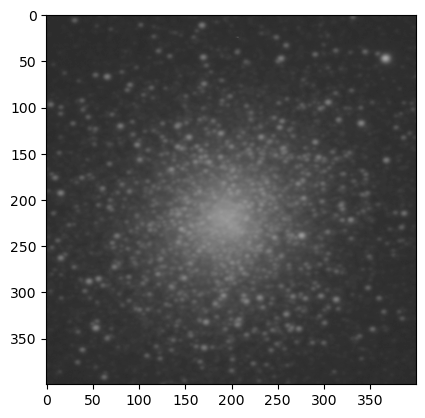

In [513]:
# open the images
imageB = fits.open(path + "twirl_B.fits")
imageR = fits.open(path + "twirl_R.fits")
print(imageB[0].header)

# crop the images
B_data = np.array(imageB[0].data, dtype=np.float32, copy=True) [1400:1800, 2200:2600]
R_data = np.array(imageR[0].data, dtype=np.float32, copy=True) [1400:1800, 2200:2600]

# plot the image
plt.imshow(B_data*1000, cmap="gray", norm=LogNorm(vmin=1, vmax=100000)) 

## Star Detection
### Calculate Sigma Clipped Statistics
We need the median value and standard deviation to use in our star detection


In [514]:
# library to use 
from astropy.stats import sigma_clipped_stats

mean, median_B, std = sigma_clipped_stats(B_data)
print(np.array((mean, median_B, std)))

mean, median_R, std = sigma_clipped_stats(R_data)
print(np.array((mean, median_R, std)))

[0.01319568 0.01080042 0.00599602]
[0.01112714 0.00965758 0.00365865]


### Star Finder
We will be using DAOFIND with median star detection for this step. Adjust the roundess limits until you have as many stars as possible

In [515]:
# library to use 
from photutils.detection import DAOStarFinder

# create a list of detected sources
daofind = DAOStarFinder(fwhm=4.0, threshold=1*std, roundlo=-1, roundhi=1.0)
sourcesB = daofind(B_data - median_B)
sourcesR = daofind(R_data - median_R)

# print one table
sourcesR

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float32
1,57.50096483459975,0.6512674495429798,0.47431675770634674,-0.539656,-0.41441732302151335,25,0.0034823753,0.01702448,4.4223156,-0.31618538
2,331.3180756554091,2.8956211978970003,0.4639639366006159,-0.3852341,-0.27906947634992024,25,0.011884029,0.11720745,2.327612,-1.339123
3,30.50558372317876,6.183369766137612,0.46250530293489317,-0.19885561,-0.38192152856277284,25,0.043232698,0.4941322,0.7653921,-2.626439
4,208.10604990969787,6.848081397558422,0.711368558671948,-0.09876582,-0.6081966098466952,25,0.01851258,0.036118,3.6056905,-1.8919618
5,101.89996392087929,11.203652305278476,0.4602436627737648,-0.21966958,-0.26631842827399715,25,0.008518894,0.0745731,2.8185444,-1.0634521
6,296.3305028779902,11.387597771484032,0.4863645151726889,-0.34553143,-0.26102568765778783,25,0.0070597744,0.06973407,2.8913877,-0.73100126
7,54.300862179496626,12.42825759274033,0.43359082356634165,-0.19100325,-0.21002613154248675,25,0.004228412,0.030621318,3.7849402,-0.4450737
8,168.1422467362194,11.631803062333066,0.4426183398748072,-0.28509375,-0.24265072207269894,25,0.19294532,2.3408072,-0.9234141,-4.234033
9,199.9131658578735,11.88336105455135,0.42127183432271037,-0.96376526,-0.3614232837567406,25,0.0023642294,0.009207978,5.089589,-0.041452825


### Plot Apertures


Draw circles around the detected sources using CircularAperture, as we did before

 ...]

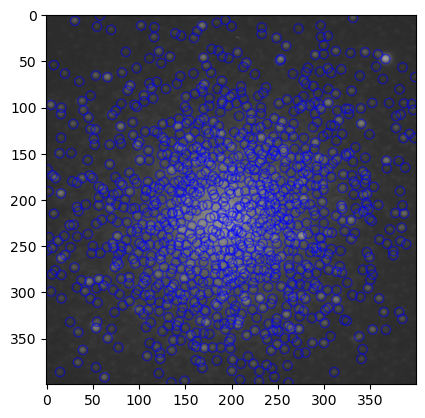

In [516]:
# library to use
from photutils.aperture import CircularAperture

# Why transpose? Hint: think about how the data is organized in a table and the expected input of CircularAperture
positions = np.transpose((sourcesB['xcentroid'], sourcesB['ycentroid']))
apertures = CircularAperture(positions, r=5.0)

# plot the image and circles
plt.imshow(B_data*1000, cmap="gray", norm=LogNorm(vmin=1, vmax=100000)) 
apertures.plot(color='blue', lw=1, alpha=0.5)

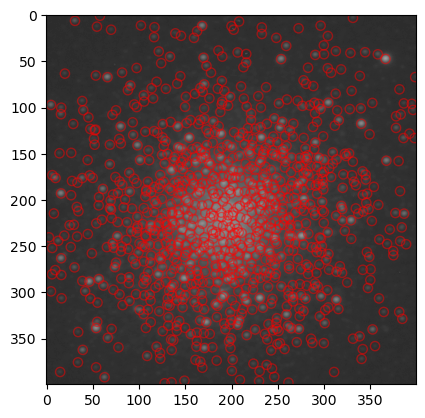

In [517]:
# repeat for second filter
positions = np.transpose((sourcesR['xcentroid'], sourcesR['ycentroid']))
apertures = CircularAperture(positions, r=5.0)

# plot the image
plt.imshow(R_data*1000, cmap="gray", norm=LogNorm(vmin=1, vmax=100000)) 
apertures.plot(color='red', lw=1, alpha=0.5)

## DEMO: Plot Image With WCS Cooridinates

This step allows you to verify if the WCS we obtained from the twirl calibration works properly

This is NOT required in your submission

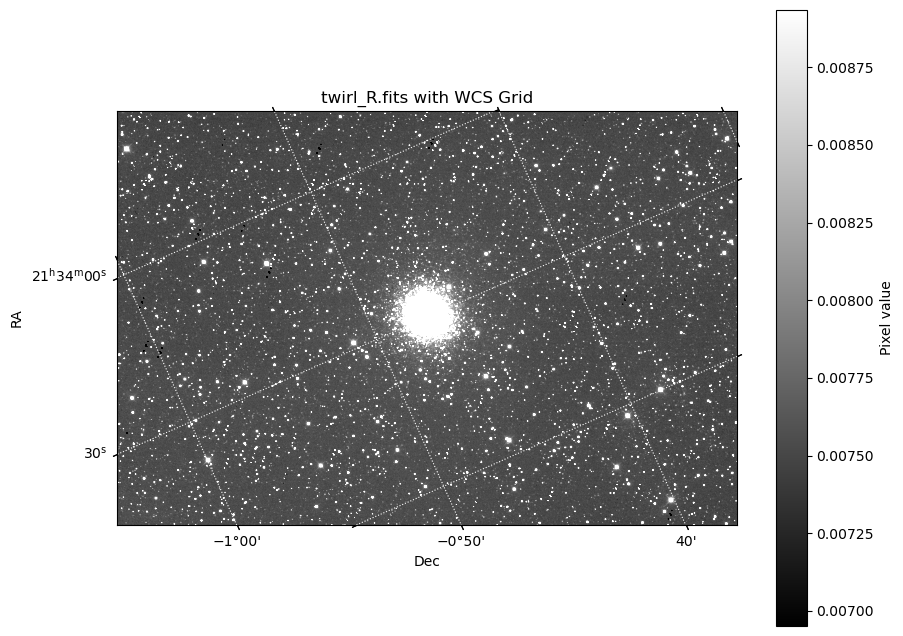

In [518]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import (ZScaleInterval, ImageNormalize)

# Load image and WCS
hdu = fits.open(path + "twirl_R.fits")[0]
wcs = WCS(hdu.header)
data = hdu.data

# # Normalize image for better contrast
norm = ImageNormalize(data, interval=ZScaleInterval())

# Plot with WCS
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(projection=wcs)
im = ax.imshow(data, origin='lower', cmap='gray', norm=norm)

# Add RA/Dec grid and labels
ax.coords.grid(True, color='white', ls='dotted')
ax.coords[0].set_axislabel('RA')
ax.coords[1].set_axislabel('Dec')

# titles and labels
plt.title("twirl_R.fits with WCS Grid")
plt.colorbar(im, ax=ax, label="Pixel value")
plt.show()

### Convert Pixel Coords into RA/DEC

We want to convert the coordiantes DAO gives us into RA/DEC so we can match them with the Stetson catalogue

In [519]:
# adjust pixel values due to crop offset
sourcesR['xcentroid'] = sourcesR['xcentroid'] + 2200
sourcesR['ycentroid'] = sourcesR['ycentroid'] + 1400
sourcesB['xcentroid'] = sourcesB['xcentroid'] + 2200
sourcesB['ycentroid'] = sourcesB['ycentroid'] + 1400

### FILTER R
# Get pixel centroids from DAOStarFinder
x = sourcesR['xcentroid']
y = sourcesR['ycentroid']

# Convert to RA/Dec
ra, dec = wcs.wcs_pix2world(x, y, 0)

# create new cols in sources
sourcesR['RA'] = ra
sourcesR['DEC'] = dec


### FILTER B
# Get pixel centroids from DAOStarFinder
x = sourcesB['xcentroid']
y = sourcesB['ycentroid']

# Convert to RA/Dec
ra, dec = wcs.wcs_pix2world(x, y, 0)

# create new cols in sources
sourcesB['RA'] = ra
sourcesB['DEC'] = dec

# print filter to view the new columns
sourcesB

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag,RA,DEC
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float32,float64,float64
1,2257.5072043051573,1400.559402297047,0.42507092196100027,-0.46668738,-0.22984502062545445,25,0.0028578574,0.004863715,5.78258,-0.36852908,323.63817596994556,-0.8106237526351858
2,2531.400049642815,1402.9616485304987,0.43290429204733505,-0.25960886,-0.3186974584098664,25,0.03987194,0.48347813,0.7890579,-2.5391288,323.64908616633625,-0.7841716272723627
3,2393.3379326036306,1405.182402484627,0.5535210220057523,0.11222995,0.13687665887990966,25,0.0051143058,0.046209916,3.338162,-0.32859153,323.64327171799005,-0.7973563551838904
4,2230.4695743604734,1406.2095165908738,0.44421042579341063,-0.3052951,-0.33380516575137287,25,0.053219534,0.6622664,0.44741824,-2.8001406,323.63655867326764,-0.8129792241451042
5,2383.9986300107507,1408.2827225272379,0.4309146905003932,-0.2321,-0.5268312705736786,25,0.006780667,0.06253801,3.0096397,-0.83241254,323.6426076630217,-0.7981200753571795
6,2302.0493881782,1411.3164186584859,0.4405233506576202,-0.18075979,-0.23177490889838973,25,0.030198196,0.35311514,1.1302091,-2.2606525,323.6389989389564,-0.8058715692012486
7,2496.414292818392,1411.3230654821857,0.43982340154863847,-0.31586656,-0.1551058883744999,25,0.0047136713,0.040739514,3.4749603,-0.4691084,323.64689706914646,-0.7871738980192321
8,2254.3242035433273,1412.4180561463481,0.41208484431701836,-0.11226571,-0.16398122128561807,25,0.0050474666,0.03641439,3.5968175,-0.6848725,323.6369583400046,-0.8104147394363675
9,2368.1701647929053,1411.660619923787,0.4386420392472822,-0.227298,-0.24282548365206316,25,0.16404235,2.1054072,-0.8083403,-4.000373,323.6416544228408,-0.7994959758200174


### DEMO: Verify Detected Stars Match Gaia Data

This step allows you to verify that your data lines up with Gaia data


This is NOT required in your submission

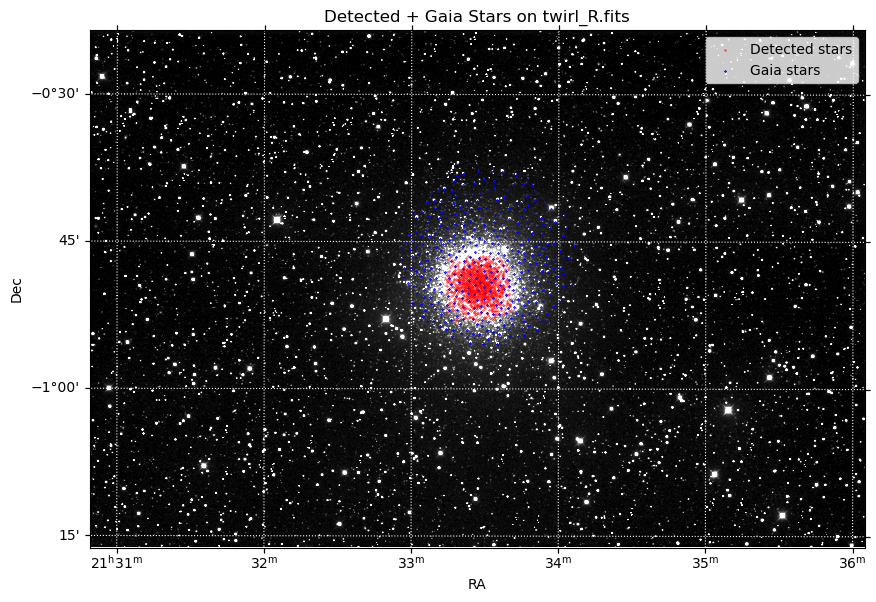

In [520]:
from twirl import gaia_radecs
from twirl.geometry import sparsify
from astropy.coordinates import SkyCoord

# fetch Gaia data
ra = imageR[0].header['RA']
dec = imageR[0].header['DEC']
all_radecs = gaia_radecs((ra, dec), 0.3)   # radius in degrees
all_radecs = sparsify(all_radecs, 0.01)
all_radecs = SkyCoord(all_radecs[:, 0], all_radecs[:, 1], unit='deg')

# open image again as background
imageR = fits.open("twirl_B.fits")
data = imageR[0].data
wcs = WCS(imageR[0].header)

# plot elements
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(projection=wcs)
ax.imshow(data, origin='lower', cmap='gray', norm=norm)
ax.coords.grid(True, color='white', ls='dotted')
norm = ImageNormalize(data, interval=ZScaleInterval())

# detected stars
x = sourcesB["xcentroid"]
y = sourcesB["ycentroid"]
ax.scatter(x, y, s=1, color='red', alpha=0.5, marker='x', label='Detected stars')

# Gaia stars
ax.scatter(all_radecs.ra, all_radecs.dec, transform=ax.get_transform('world'), s=1, color='blue', alpha=0.8, marker='x', label='Gaia stars')

# lables
ax.coords[0].set_axislabel('RA')
ax.coords[1].set_axislabel('Dec')
plt.title("Detected + Gaia Stars on twirl_R.fits")
plt.legend()
plt.show()

## Stetson Matching

This was originally supposed to be done by hand but proved too complicated. You have been provided a file that has merged your detected magnitudes along with the Stetson magnitudes.

In [554]:
import pandas as pd
full = pd.read_csv(path + "detected_stetson.csv")
full

,det_magR,RA,DEC,Reference,R,B,det_magB
0,2.327612,323.400350,-0.883217,M2-S24,16.250,16.318,0.789058
1,2.818544,323.337216,-0.881042,M2-S806,16.571,16.597,1.130209
2,2.084390,323.353931,-0.879301,M2-S509,16.299,17.507,1.873621
3,1.814598,323.342500,-0.873310,M2-S487,15.940,16.263,0.632369
4,0.982897,323.407747,-0.872337,M2-S95,15.270,16.583,0.763622
...,...,...,...,...,...,...,...
167,2.160025,323.342815,-0.781800,M2-S488,16.271,16.347,0.714443
168,1.005938,323.364383,-0.781484,M2-S525,15.317,16.609,0.725337
169,1.607678,323.374496,-0.779907,M2-S537,15.786,17.031,1.326617
170,4.090312,323.394596,-0.777750,M2-S565,17.302,17.164,1.882458


### Linear Data Calibration

We can determine a relationship between our data and the Stetson data, and use that to adjut all of our observed sources

Use the equation given in the plot to calibrate your data

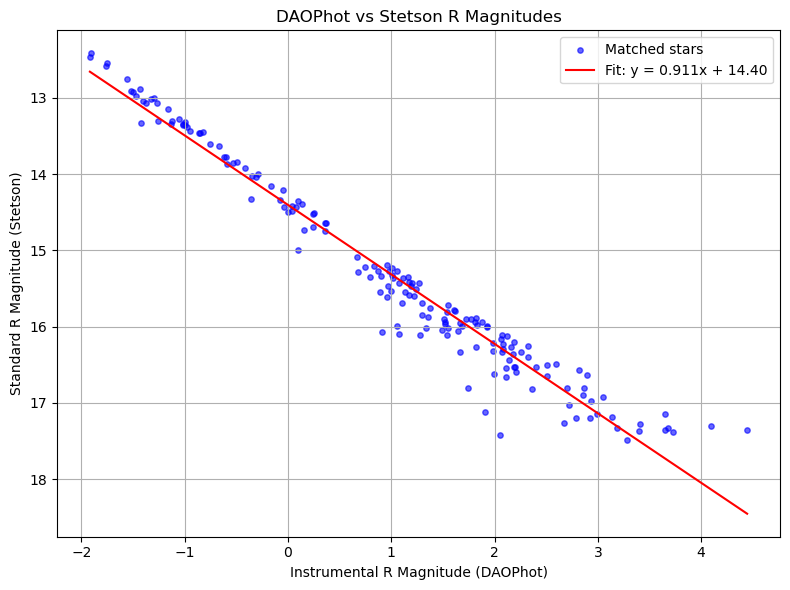

In [522]:
# for R filter first
R_inst = full["det_magR"]   # instrumental sources from DAOPhot
R_stetson = full["R"]  # from Stetson

# linear fit
slope, intercept, r_value, p_value, std_err = linregress(R_inst, R_stetson)

# generate best-fit line
x_fit = np.linspace(min(R_inst), max(R_inst), 100)
y_fit = slope * x_fit + intercept

# plot
plt.figure(figsize=(8,6))
plt.scatter(R_inst, R_stetson, s=15, color='blue', alpha=0.6, label='Matched stars')
plt.plot(x_fit, y_fit, color='red', label=f'Fit: y = {slope:.3f}x + {intercept:.2f}')
plt.xlabel('Instrumental R Magnitude (DAOPhot)')
plt.ylabel('Standard R Magnitude (Stetson)')
plt.title('DAOPhot vs Stetson R Magnitudes')
plt.legend()
plt.grid(True)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

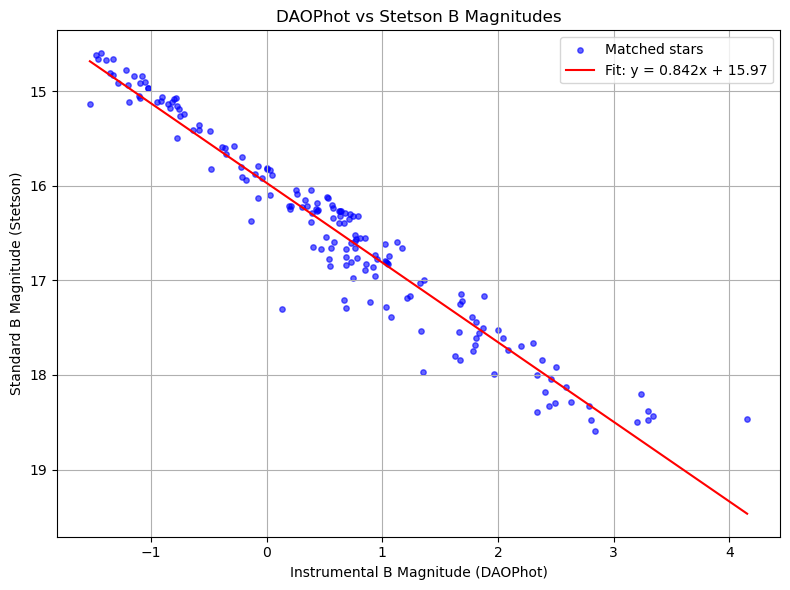

In [544]:
# for B filter
R_inst = full["det_magB"]   # # instrumental sources from DAOPhot
R_stetson = full["B"]  # from Stetson

# linear fit
slope, intercept, r_value, p_value, std_err = linregress(R_inst, R_stetson)

# generate best-fit line
x_fit = np.linspace(min(R_inst), max(R_inst), 100)
y_fit = slope * x_fit + intercept

# plot
plt.figure(figsize=(8,6))
plt.scatter(R_inst, R_stetson, s=15, color='blue', alpha=0.6, label='Matched stars')
plt.plot(x_fit, y_fit, color='red', label=f'Fit: y = {slope:.3f}x + {intercept:.2f}')
plt.xlabel('Instrumental B Magnitude (DAOPhot)')
plt.ylabel('Standard B Magnitude (Stetson)')
plt.title('DAOPhot vs Stetson B Magnitudes')
plt.legend()
plt.grid(True)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Apply Corrections to Observed Data

Use the equations given in the plots above to calibrate your data

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


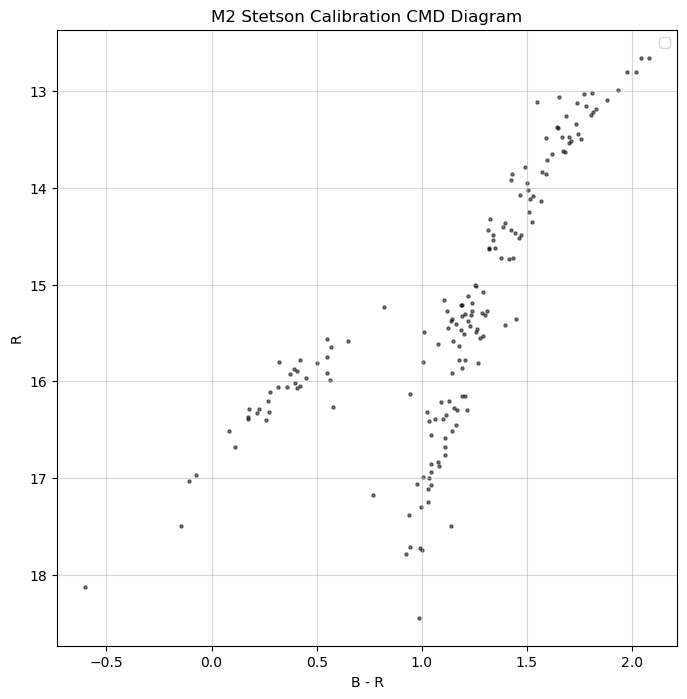

In [545]:
# apply corrections
R_mags = 0.91 * full["det_magR"] + 14.4
B_mags = 0.84 * full["det_magB"] + 15.94

# magnitude subtraction
colour = B_mags - R_mags

# plot data
fig, ax = plt.subplots(figsize=(8,8))
ax.set_title("M2 Stetson Calibration CMD Diagram")
ax.set_xlabel("B - R")
ax.set_ylabel("R")
ax.scatter(colour, R_mags, s=5, alpha=0.5, color="black") 
ax.grid(alpha=0.5)
ax.invert_yaxis()
ax.legend()
plt.show()

## Plot Data Against Isochrone to Determine Age

We used this online isochrone generator: https://stev.oapd.inaf.it/cgi-bin/cmd_3.8

This gives us an isochrone based on the composition of the cluster, we will plot our data to see if it matches

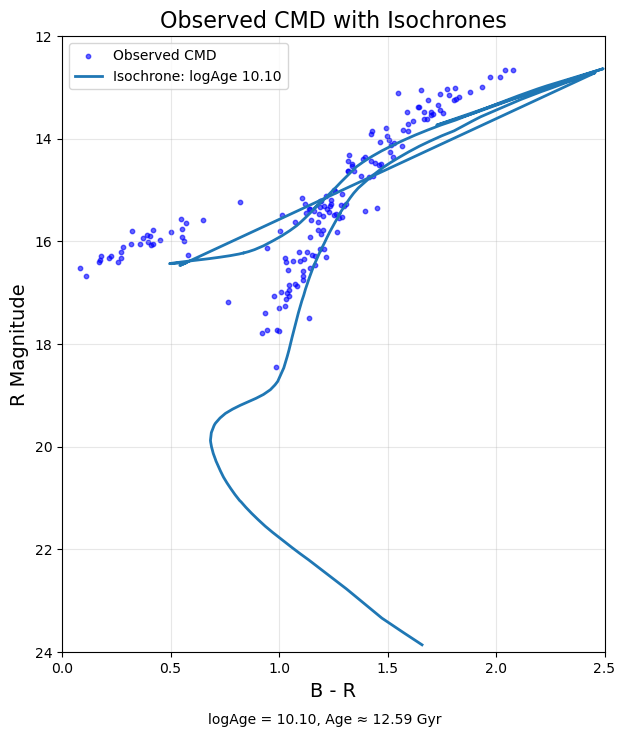

logAge = 10.10, Age ≈ 12.59 Gyr


In [546]:
# load isochrone
iso_file = "isochrone.dat.txt"
distance_modulus = 16.15  # calculated for M2

# Column names based on isochrone file
columns = [
    'Zini','MH','logAge','Mini','int_IMF','Mass','logL','logTe','logg',
    'label','McoreTP','C_O','period0','period1','period2','period3','period4',
    'pmode','Mloss','tau1m','X','Y','Xc','Xn','Xo','Cexcess','Z',
    'mbolmag','Umag','Bmag','Vmag','Rmag','Imag','Jmag','Hmag','Kmag'
]

# Load isochrone file
iso = pd.read_csv(iso_file, sep=r"\s+", comment="#", names=columns)

# Set chart limit magnitudes
fig, ax = plt.subplots(figsize=(7, 8))
ax.set_xlim(0, 2.5)  
ax.set_ylim(24, 12) 

# Plot the CMD
ax.scatter(colour, R_mags, s=10, alpha=0.6, color='blue', label='Observed CMD')

# Group by age if multiple isochrones
for age, group in iso.groupby('logAge'):
    color = group['Bmag'] - group['Rmag']
    mag_R = group['Rmag'] + distance_modulus

    # Apply mask to set magnitude limits
    mask = (color > 0) & (color < 2.5) & (mag_R > 12) & (mag_R < 24)
    ax.plot(color[mask], mag_R[mask], lw=2, label=f'Isochrone: logAge {age:.2f}')

# Plot settings
ax.set_xlabel('B - R', fontsize=14)
ax.set_ylabel('R Magnitude', fontsize=14)
ax.set_title('Observed CMD with Isochrones', fontsize=16)
ax.legend()
ax.grid(alpha=0.3)
text = fig.text(0.50, 0.02, 'logAge = 10.10, Age ≈ 12.59 Gyr',  horizontalalignment='center', wrap=True )
plt.show()

# if multiple isochrones
for age, group in iso.groupby('logAge'):
    age_gyr = 10**age / 1e9
    print(f"logAge = {age:.2f}, Age ≈ {age_gyr:.2f} Gyr")

### Align Detected Sources

The DAO sources for R and B are not aligned, this code makes it the same row in each table is the same star 

In [551]:
import numpy as np
import pandas as pd

# Convert QTables to pandas
sourcesB_df = sourcesB.to_pandas()
sourcesR_df = sourcesR.to_pandas()

# Rename for consistent naming
sourcesB_df = sourcesB_df.rename(columns={'mag': 'det_magB'})
sourcesR_df = sourcesR_df.rename(columns={'mag': 'det_magR'})
# sourcesR_df already has det_magR

# Pixel coordinates
x_B = sourcesB_df['xcentroid'].values
y_B = sourcesB_df['ycentroid'].values
x_R = sourcesR_df['xcentroid'].values
y_R = sourcesR_df['ycentroid'].values

tolerance = 2  # pixels
matched_indices_B = []
matched_indices_R = []

for i, (xb, yb) in enumerate(zip(x_B, y_B)):
    dist = np.sqrt((x_R - xb)**2 + (y_R - yb)**2)
    j = np.argmin(dist)

    if dist[j] <= tolerance:
        matched_indices_B.append(i)
        matched_indices_R.append(j)

print(f"Matched {len(matched_indices_B)} stars within {tolerance} px")

# ⬇️ Build aligned DataFrames
aligned_B = sourcesB_df.iloc[matched_indices_B].reset_index(drop=True)
aligned_R = sourcesR_df.iloc[matched_indices_R].reset_index(drop=True)

# aligned_B[i] corresponds to aligned_R[i]

Matched 906 stars within 2 px


### Repeat CMD Plot With All Data

Same as before just with all our DAO sources

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


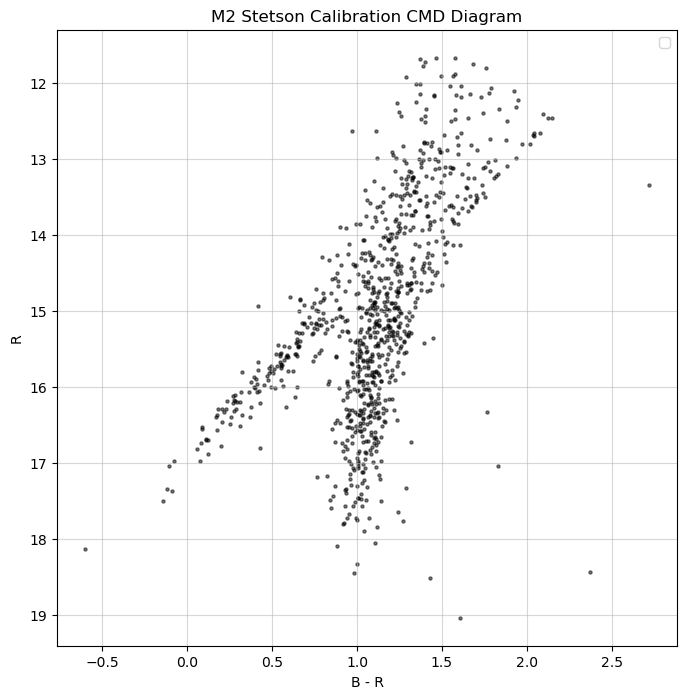

In [552]:
# apply corrections
R_mags = 0.91 * aligned_R["det_magR"] + 14.4
B_mags = 0.84 * aligned_B["det_magB"] + 15.94

# magnitude subtraction
colour = B_mags - R_mags

# plot data
fig, ax = plt.subplots(figsize=(8,8))
ax.set_title("M2 Stetson Calibration CMD Diagram")
ax.set_xlabel("B - R")
ax.set_ylabel("R")
ax.scatter(colour, R_mags, s=5, alpha=0.5, color="black") 
ax.grid(alpha=0.5)
ax.invert_yaxis()
ax.legend()
plt.show()

### Repeat Isochrone Plot With All Data

Same as before just with all our DAO sources

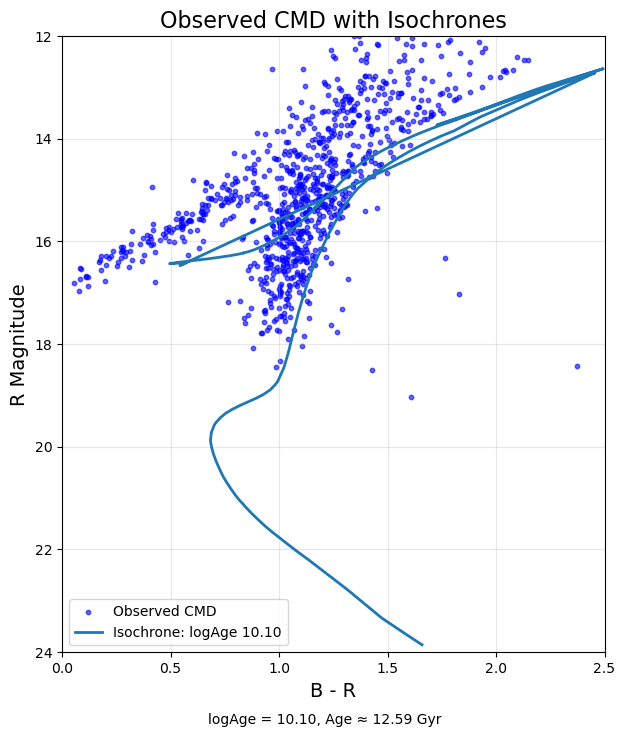

logAge = 10.10, Age ≈ 12.59 Gyr


In [553]:
# load isochrone
iso_file = "isochrone.dat.txt"
distance_modulus = 16.15  # calculated for M2

# Column names based on isochrone file
columns = [
    'Zini','MH','logAge','Mini','int_IMF','Mass','logL','logTe','logg',
    'label','McoreTP','C_O','period0','period1','period2','period3','period4',
    'pmode','Mloss','tau1m','X','Y','Xc','Xn','Xo','Cexcess','Z',
    'mbolmag','Umag','Bmag','Vmag','Rmag','Imag','Jmag','Hmag','Kmag'
]

# Load isochrone file
iso = pd.read_csv(iso_file, sep=r"\s+", comment="#", names=columns)

# Set chart limit magnitudes
fig, ax = plt.subplots(figsize=(7, 8))
ax.set_xlim(0, 2.5)  
ax.set_ylim(24, 12) 

# Plot the CMD
ax.scatter(colour, R_mags, s=10, alpha=0.6, color='blue', label='Observed CMD')

# Group by age if multiple isochrones
for age, group in iso.groupby('logAge'):
    color = group['Bmag'] - group['Rmag']
    mag_R = group['Rmag'] + distance_modulus

    # Apply mask to set magnitude limits
    mask = (color > 0) & (color < 2.5) & (mag_R > 12) & (mag_R < 24)
    ax.plot(color[mask], mag_R[mask], lw=2, label=f'Isochrone: logAge {age:.2f}')

# Plot settings
ax.set_xlabel('B - R', fontsize=14)
ax.set_ylabel('R Magnitude', fontsize=14)
ax.set_title('Observed CMD with Isochrones', fontsize=16)
ax.legend()
ax.grid(alpha=0.3)
text = fig.text(0.50, 0.02, 'logAge = 10.10, Age ≈ 12.59 Gyr',  horizontalalignment='center', wrap=True )
plt.show()

# if multiple isochrones
for age, group in iso.groupby('logAge'):
    age_gyr = 10**age / 1e9
    print(f"logAge = {age:.2f}, Age ≈ {age_gyr:.2f} Gyr")